How to Integrate Tools with Agents

In [1]:
import os

from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Initiating model

from langchain.chat_models import init_chat_model

model = init_chat_model(
    model = "llama-3.1-8b-instant",
    model_provider = "groq",
)

res = model.invoke("Hello, how are you?")
res  # Tht Type of AI response is AIMessage
print(res.content)


I'm functioning properly, thanks for asking. I'm here to provide information and help with any questions you may have. How can I assist you today?


Tools definning

In [17]:
from langchain.tools import tool

@tool
def add(x: int, y: int) -> int:
    """ Add two number """
    return x + y
@tool
def get_weather(location : str) -> str:
    """ Get the weather for a location """
    return f"The weather in {location} is sunny"


1. Tool Calling

In [18]:
model_with_tools = model.bind_tools([add, get_wheather])

res = model_with_tools.invoke("What is the weather in New York?")
res = model_with_tools.invoke("What is sum of 2 + 2?")
print(res)
print(res.tool_calls)



content='' additional_kwargs={'tool_calls': [{'id': 'tnh16fh5e', 'function': {'arguments': '{"x":2,"y":2}', 'name': 'add'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 277, 'total_tokens': 295, 'completion_time': 0.038763229, 'completion_tokens_details': None, 'prompt_time': 0.017060346, 'prompt_tokens_details': None, 'queue_time': 0.005702319, 'total_time': 0.055823575}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019ce6ea-3264-78a1-800d-2ae67c11db30-0' tool_calls=[{'name': 'add', 'args': {'x': 2, 'y': 2}, 'id': 'tnh16fh5e', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 277, 'output_tokens': 18, 'total_tokens': 295}
[{'name': 'add', 'args': {'x': 2, 'y': 2}, 'id': 'tnh16fh5e', 'type': 'tool_call'}]


2. Tool Execution Loop

In [32]:
from langchain.tools import tool
from langchain_core.messages import HumanMessage, ToolMessage
import json

# --------------------------
# Tool Definitions
# --------------------------

@tool
def add(x: int, y: int) -> int:
    """Add two numbers"""
    return x + y


@tool
def get_weather(location: str) -> str:
    """Get the weather for a location"""
    return f"The weather in {location} is sunny"


# --------------------------
# Step 1: Tool Calling
# --------------------------

messages = [
    HumanMessage(content="What is the weather in New York?"),
    HumanMessage(content="What is the sum of 2 + 2?")
]

# Call model
ai_msg = model_with_tools.invoke(messages)

messages.append(ai_msg)


# --------------------------
# Step 2: Tool Execution
# --------------------------

tool_map = {
    "add": add,
    "get_weather": get_weather,
}

for tool_call in ai_msg.tool_calls:

    tool_name = tool_call["name"]
    tool_args = tool_call["args"]

    if tool_name in tool_map:

        result = tool_map[tool_name].invoke(tool_args)

        messages.append(
            ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"]
            )
        )

    else:
        print(f"Tool '{tool_name}' not found")


print(messages)


# --------------------------
# Step 3: Final Model Response
# --------------------------

res = model_with_tools.invoke(messages)

print(res)

Tool 'get_wheather' not found
[HumanMessage(content='What is the weather in New York?', additional_kwargs={}, response_metadata={}), HumanMessage(content='What is the sum of 2 + 2?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'w6cecjm8e', 'function': {'arguments': '{"location":"New York"}', 'name': 'get_wheather'}, 'type': 'function'}, {'id': 'd0s1ym5vx', 'function': {'arguments': '{"x":2,"y":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 291, 'total_tokens': 325, 'completion_time': 0.046347335, 'completion_tokens_details': None, 'prompt_time': 0.018635055, 'prompt_tokens_details': None, 'queue_time': 0.005166019, 'total_time': 0.06498239}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ce6f5-5ea3-77a1

In [33]:
messages

[HumanMessage(content='What is the weather in New York?', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='What is the sum of 2 + 2?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'w6cecjm8e', 'function': {'arguments': '{"location":"New York"}', 'name': 'get_wheather'}, 'type': 'function'}, {'id': 'd0s1ym5vx', 'function': {'arguments': '{"x":2,"y":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 291, 'total_tokens': 325, 'completion_time': 0.046347335, 'completion_tokens_details': None, 'prompt_time': 0.018635055, 'prompt_tokens_details': None, 'queue_time': 0.005166019, 'total_time': 0.06498239}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ce6f5-5ea3-77a1-97d4-511c83960aaa-0', tool_

In [34]:
model_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001FC52FC3EC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001FC53158860>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'Add two number', 'parameters': {'properties': {'x': {'type': 'integer'}, 'y': {'type': 'integer'}}, 'required': ['x', 'y'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'get_wheather', 'description': 'Get the weather for a location', 'parameters': {'properties': {'location': {'type': 'string'}}, 'required': ['location'], 'type': 'object'}}}]},

Agent using inbuilt function in langchain

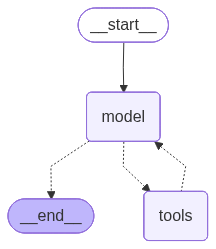

In [36]:
from langchain.agents import create_agent

agent = create_agent(
    model = model,
    tools = [add, get_weather],
    system_prompt = "You are a helpful assistant.",
)
agent

In [53]:
res = agent.invoke({"messages": [
    {"role": "user", "content": "What is the weather like in karachi?"},
    {"role": "user", "content": "What is the sum of 2 +2 ?"}
    ]})

print(res)
res['messages'][-1].content

{'messages': [HumanMessage(content='What is the weather like in karachi?', additional_kwargs={}, response_metadata={}, id='1fc02033-7be4-46fb-a4c3-4a40d2e828c6'), HumanMessage(content='What is the sum of 2 +2 ?', additional_kwargs={}, response_metadata={}, id='267759da-4de3-49b0-8d37-31a7a2b98e00'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'wq1kwqsdt', 'function': {'arguments': '{"location":"karachi"}', 'name': 'get_weather'}, 'type': 'function'}, {'id': 'yv0th44we', 'function': {'arguments': '{"x":2,"y":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 293, 'total_tokens': 324, 'completion_time': 0.054598762, 'completion_tokens_details': None, 'prompt_time': 0.016693592, 'prompt_tokens_details': None, 'queue_time': 0.00527132, 'total_time': 0.071292354}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'log

'The sum of 2 + 2 is 4.'